In [26]:
import networkx as nx
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm as tqdm
import pandas as pd
from collections import Counter
import statistics as stat
import seaborn as sns

In [ ]:
# Will actually use functions for each part since that makes this WAY easier
# Also using the double swap by network x is way slower (would take over 15 hours on kaggle).
#
def degree_preserving_swap(G, number_of_swaps=698955, seed=24):

    # First make a copy of the graph.
    # And make a list of all the edges for random selection later
    G_random = G.copy()
    edges = list(G_random.edges())

    # This is to avoid infinite loops
    max_attempts = 20
    attempts = 0
    successful_swaps = 0
    while successful_swaps < number_of_swaps and attempts < max_attempts:

        # We pick two random edges and get their nodes
        # https://www.w3schools.com/python/ref_random_sample.asp
        index1, index2 = random.sample(range(len(edges)), k=2)
        first_edge = edges[index1]
        second_edge = edges[index2]

        # Each edge has TWO nodes
        first_node1 = first_edge[0]
        first_node2 = first_edge[1]
        second_node1 = second_edge[0]
        second_node2 = second_edge[1]

        # We now check to see if these edges are the same node.
        # You can't swap in this case
        if first_node1 == second_node1 or first_node2 == second_node2 \
            or second_node1 == first_node2 or second_node1 == first_node2:
            attempts += 1
            continue

        # Otherwise, they aren't, so we can continue. The new edge is just SWAPPING those nodes.
        new_first_edge = (first_node1, second_node2)
        new_second_edge = (second_node1, first_node2)

        # However, these edges may already exist, so we check that first.
        # ALSO, literally all of network x's functions need inputs u and v.
        # It is so much easier to just unpack the tuple using an asterik for input.
        # Makes it clearer as well.
        if G_random.has_edge(*new_first_edge) or G_random.has_edge(*new_second_edge):
            attempts += 1
            continue

        # Then we just remove the edge and add the other edge.
        # This is the swap
        G_random.remove_edge(*first_edge)
        G_random.remove_edge(*second_edge)

        # These are the new edges we are adding
        G_random.add_edge(*new_first_edge)
        G_random.add_edge(*new_second_edge)

        # Updating the list...
        edges[index1] = new_first_edge
        edges[index2] = new_second_edge

        successful_swaps += 1
        attempts += 1

    return G_random


In [ ]:
def generate_null_models(G, number_of_networks=1000, seed=24):

    # This is the number of swaps
    # It is the number of edges in my network multipled by 5.
    # I am doing 5 swaps.
    number_of_swaps = 698955
    all_null_models = []

    with tqdm(total=number_of_networks) as progress_bar:
        for index in range(number_of_networks):
            G_random = degree_preserving_swap(G, number_of_swaps, seed=24)
            all_null_models.append(G_random)
            progress_bar.update(1)

    return all_null_models

In [ ]:
# THIS IS THE EXACT SAME CODE I USED IN THE caculationsGraph file.
# Function to calculate paths with progress
# Must more optimized using nx.single_source_shortest_path_length instead of calculating each pair separately
# Plus I can see progress
def calculate_paths_with_progress(graph):
    all_nodes = list(graph.nodes())
    number_of_nodes = len(all_nodes)

    total_paths = 0
    length_of_paths = 0
    max_length_path = 0

    with tqdm(total=number_of_nodes, desc="Calculating node paths") as progress_bar:
        for node_source in all_nodes:

            # https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.shortest_paths.unweighted.single_source_shortest_path.html#networkx.algorithms.shortest_paths.unweighted.single_source_shortest_path
            paths = nx.single_source_shortest_path_length(graph, node_source)

            for node_target, length in paths.items():

                # To avoid self loops cause that isn't needed (would just be 0)
                if node_target != node_source:
                    length_of_paths += length
                    max_length_path = max(max_length_path, length)
                    total_paths += 1

            progress_bar.update(1)

    average_length = length_of_paths / total_paths

    return average_length, max_length_path

In [ ]:
def analyze_community(graph):
    # Here, we just analyze the community structure using Louvain method.
    # I won't use a seed here since it can help add to the randomness I guess...
    louvain_communities = nx.community.louvain_communities(graph)

    # Now we can calculate the modularity
    # https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.community.quality.modularity.html
    modularity_of_communities = nx.community.modularity(graph, louvain_communities)

    number_of_communities = len(louvain_communities)
    community_sizes = [len(community) for community in louvain_communities]

    # Will use statistics library again for this..
    average_community_size = stat.mean(community_sizes)
    min_community_size = min(community_sizes)
    max_community_size = max(community_sizes)
    community_size_standard = stat.stdev(community_sizes)

    communitiy_metrics = {
        "modularity": modularity_of_communities,
        "number_of_communities": number_of_communities,
        "average_community_size": average_community_size,
        "min_community_size": min_community_size,
        "max_community_size": max_community_size,
        "community_size_standard": community_size_standard
    }

    return communitiy_metrics

In [ ]:
# Now we can start the null model creations
null_clustering = []
null_paths = []
null_diameters = []
null_modularity = []
null_number_of_communities = []
null_average_community_size = []
null_min_community_size = []
null_max_community_size = []
null_community_size_standard = []

G = nx.read_graphml("./NetworkFiles/network_graph_symptom.graphml")

# Then we generate the null models
all_null_models = generate_null_models(G, number_of_networks=1000, seed=24)

print("ANALYZING THE NULL MODELS!")
with tqdm(total=len(all_null_models), desc="Analyzing the null models") as progres_bar:
    for index in range(len(all_null_models)):
        G_null = all_null_models[index]

        # Deal with the clustering
        null_clustering = nx.clustering(G_null)
        null_clustering.append(nx.clustering(null_clustering))

        # Then the path length
        null_average_path, null_diameter = calculate_paths_with_progress(G_null)
        null_paths.append(null_average_path)
        null_diameters.append(null_diameter)

        # Then the community
        community_metrics = analyze_community(G_null)
        null_modularity.append(community_metrics["modularity"])
        null_number_of_communities.append(community_metrics["number_of_communities"])
        null_average_community_size.append(community_metrics["average_community_size"])
        null_min_community_size.append(community_metrics["min_community_size"])
        null_max_community_size.append(community_metrics["max_community_size"])
        null_community_size_standard.append(community_metrics["community_size_standard"])

        progres_bar.update(1)

results = {
    "null_clustering": null_clustering,
    "null_paths": null_paths,
    "null_diameters": null_diameters,
    "null_modularity": null_modularity,
    "null_number_of_communities": null_number_of_communities,
    "null_average_community_size": null_average_community_size,
    "null_min_community_size": null_min_community_size,
    "null_max_community_size": null_max_community_size,
    "null_community_size_standard": null_community_size_standard,
}


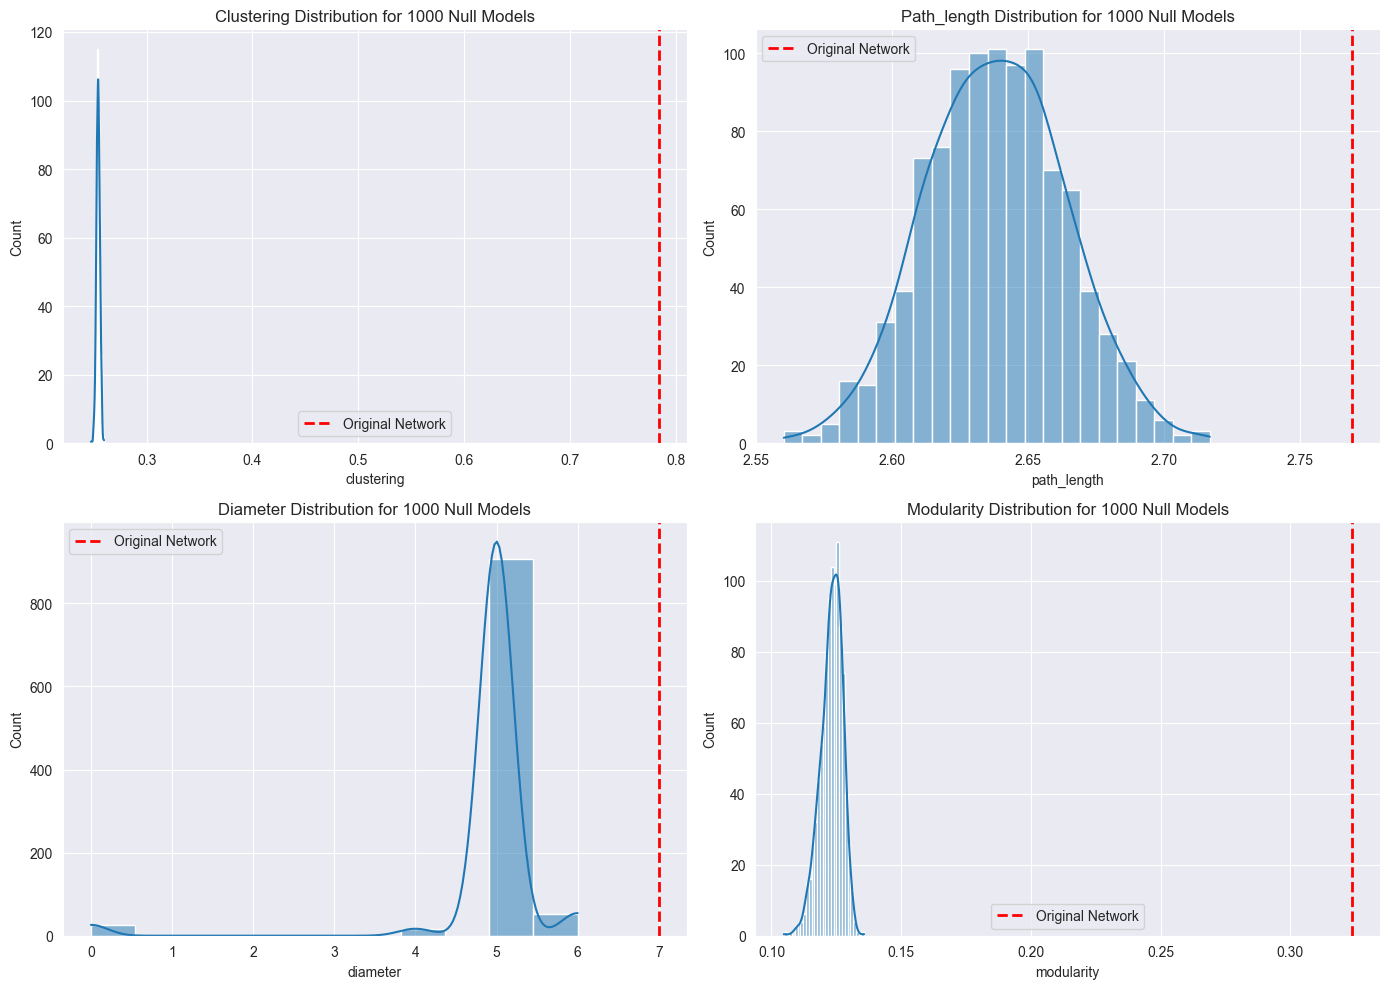

In [36]:
# Getting the values I got from kaggle, I will use these to plot against my original network values
# USED KAGGLE BECAUSE IT WAS TAKING SO LONGGG
null_model_iterations = pd.read_csv("./NetworkFiles/null_model_iterations.csv")

# Needs to match the same column title as in the csv...
actual_values = {
    "clustering": 0.7838,
    "path_length": 2.769,
    "diameter": 7.000,
    "modularity": 0.3236,
    "num_communities": 86,
    "avg_community_size": 99.94,
    "max_community_size": 1741,
    "community_size_variation": 334.0
}

# Then for just through each metric we wanted to look into.
# So clustering, path length, diameter, and modularity (for the stuff I talked about in community.
metrics = ['clustering', 'path_length', 'diameter', 'modularity']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for index, metric in enumerate(metrics):
    ax = axes[index]
    sns.histplot(null_model_iterations[metric], kde=True, ax=ax)
    ax.axvline(actual_values[metric], color='red', linestyle='--',
               linewidth=2, label='Original Network')
    ax.set_title(f'{metric.capitalize()} Distribution for 1000 Null Models')
    ax.legend()

plt.tight_layout()
plt.savefig('null_model_distributions.png', dpi=300)
